# **Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import zipfile
import os
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import  transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader




## **Import Dataset**

In [3]:
zip_path = "/content/Dataset.zip"
extract_path = "/content/Dataset"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

dataset_path = extract_path

# **Data Preprocessing**

In [4]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = ImageFolder(root=extract_path, transform=transform)

dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


Number of training samples: 1369
Number of classes: 3
Classes: ['Normal', 'Papilledema', 'Pseudopapilledema']


Shape of a batch of images: torch.Size([32, 3, 64, 64])
Shape of a batch of labels: torch.Size([32])


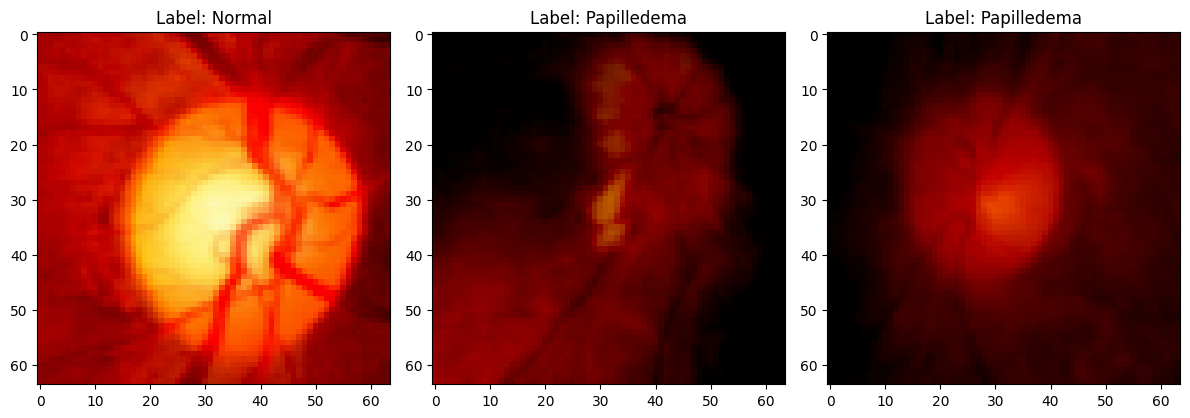

In [5]:
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of classes: {len(train_dataset.classes)}")
print(f"Classes: {train_dataset.classes}")

data_iter = iter(dataloader)
images, labels = next(data_iter)

print(f"Shape of a batch of images: {images.shape}")
print(f"Shape of a batch of labels: {labels.shape}")


plt.figure(figsize=(12, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(images[i].permute(1, 2, 0).cpu().numpy())
    plt.title(f"Label: {train_dataset.classes[labels[i]]}")
plt.tight_layout()
plt.show()


# **Set Hyperpatameters**

In [15]:
latent_dim = 100
lr = 0.002
beta1 = 0.5
beta2 = 0.999
num_epochs = 30

# **Model**

## **Generator**

In [7]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128 * 8 * 8),
            nn.ReLU(),
            nn.Unflatten(1, (128, 8, 8)),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128, momentum=0.78),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64, momentum=0.78),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 3, kernel_size=3, padding=1),
            nn.Tanh())

    def forward(self, z):
        img = self.model(z)
        return img

## **Discriminator**

In [8]:
class Discriminator (nn.Module):
  def __init__(self):
    super (Discriminator, self).__init__()
    self.model = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
    nn.LeakyReLU(0.2),
    nn. Dropout (0.25),
    nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
    nn.ZeroPad2d((0, 1, 0, 1)),
    nn. BatchNorm2d (64, momentum=0.82),
    nn.LeakyReLU(0.25),
    nn. Dropout (0.25),
    nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
    nn.BatchNorm2d(128, momentum=0.82),
    nn.LeakyReLU(0.2),
    nn. Dropout (0.25),
    nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(256, momentum=0.8),
    nn.LeakyReLU(0.25),
    nn. Dropout (0.25),
    nn.Flatten(),
    nn.Linear(256*9*9, 1),
    nn.Sigmoid())

  def forward(self, img):
    validity = self.model(img)
    return validity


## **Full model**

In [9]:
generator = Generator (latent_dim).to(device)
discriminator = Discriminator().to(device)

# Loss function
adversarial_loss = nn. BCELoss()
# Optimizers
optimizer_G = optim.Adam (generator.parameters(),lr=lr, betas=(beta1, beta2))
optimizer_D = optim.Adam(discriminator.parameters(),lr=lr, betas=(beta1, beta2))

## **Fitting Model**

 Epoch [10/30] Batch 43/43Discriminator Loss: 0.3814Generator Loss: 2.5764


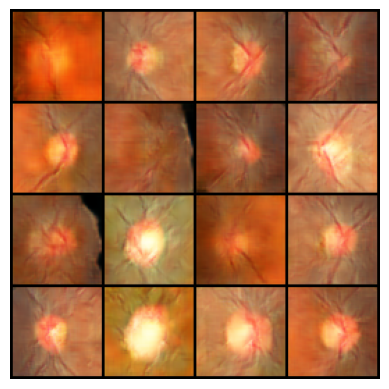

 Epoch [20/30] Batch 43/43Discriminator Loss: 0.6263Generator Loss: 1.6084


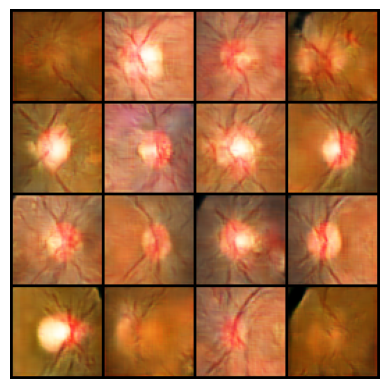

 Epoch [30/30] Batch 43/43Discriminator Loss: 0.6107Generator Loss: 1.5873


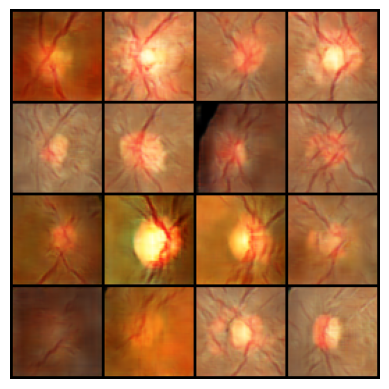

In [24]:
g_losses_per_epoch = []
d_losses_per_epoch = []

for epoch in range(num_epochs):
    epoch_g_loss = 0.0
    epoch_d_loss = 0.0
    for i, batch in enumerate(dataloader):
        real_images = batch[0].to(device)

        valid = torch.ones(real_images.size(0), 1, device=device)
        fake = torch.zeros(real_images.size(0), 1, device=device)

        real_images = real_images.to(device)

        optimizer_D.zero_grad()

        z = torch.randn(real_images.size(0), latent_dim, device=device)
        fake_images = generator(z)

        real_loss = adversarial_loss(discriminator(real_images), valid)
        fake_loss = adversarial_loss(discriminator(fake_images.detach()), fake)
        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()

        optimizer_G.zero_grad()
        gen_images = generator(z)
        g_loss = adversarial_loss(discriminator(gen_images), valid)
        g_loss.backward()
        optimizer_G.step()

        # Accumulate losses for the epoch
        epoch_g_loss += g_loss.item()
        epoch_d_loss += d_loss.item()

    # Average losses for the epoch
    g_losses_per_epoch.append(epoch_g_loss / len(dataloader))
    d_losses_per_epoch.append(epoch_d_loss / len(dataloader))

    # Save generated images for every epoch
    if (epoch + 1) % 10 == 0:
        print(f" Epoch [{epoch+1}/{num_epochs}] Batch {i+1}/{len(dataloader)}"
        f"Discriminator Loss: {d_loss.item():.4f}"
        f"Generator Loss: {g_loss.item():.4f}")
        with torch.no_grad():
          z = torch.randn (16, latent_dim, device=device)
          generated = generator(z).detach().cpu()
          grid = torchvision.utils.make_grid (generated, nrow=4, normalize=True)
          plt.imshow(np.transpose(grid, (1, 2, 0)))
          plt.axis("off")
          plt.show()

## **Loss per epochs**

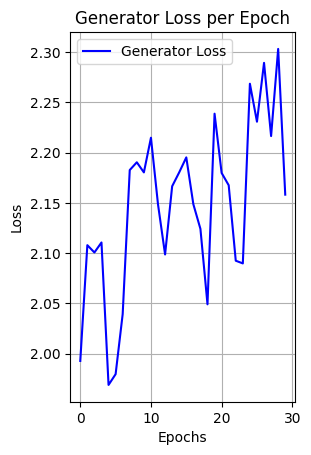

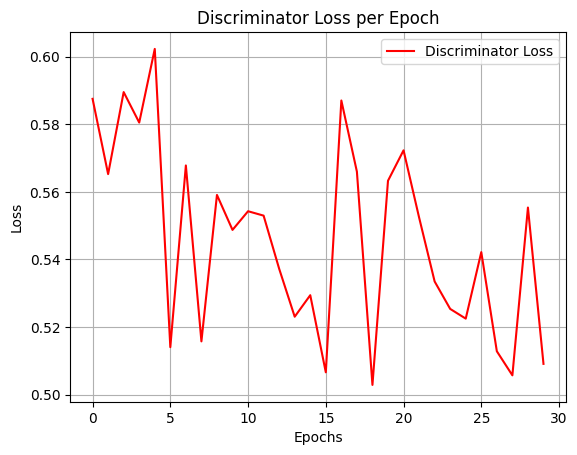

In [25]:
# Separate plots
plt.subplot(1, 2, 2)
plt.plot(g_losses_per_epoch, label='Generator Loss', color='blue')
plt.title('Generator Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.figure()
plt.plot(d_losses_per_epoch, label='Discriminator Loss', color='red')
plt.title('Discriminator Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

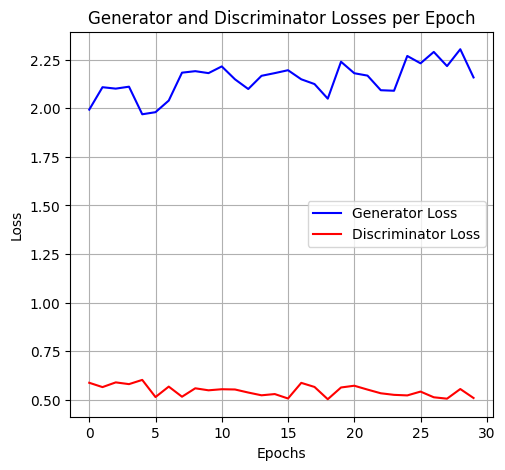

In [26]:
# Plotting the losses per epoch
plt.figure(figsize=(12, 5))

# Combined plot
plt.subplot(1, 2, 1)
plt.plot(g_losses_per_epoch, label='Generator Loss', color='blue')
plt.plot(d_losses_per_epoch, label='Discriminator Loss', color='red')
plt.title('Generator and Discriminator Losses per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()